/home/ebertp/work/projects/chrom-y-extended
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/region-overlap-stats
=== source path
codebase/plotting/notebooks/region-overlap-stats/issue-by-group.ipynb
Panel main fig. 1
===


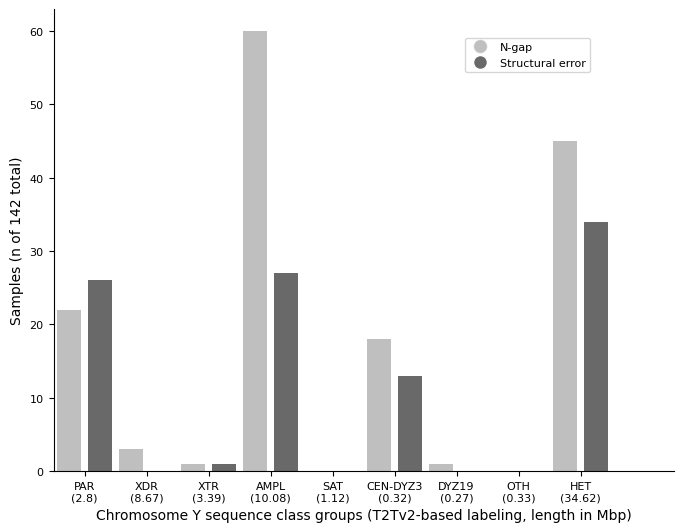

In [50]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
TABLE_ROOT = CONFIG["table_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

print(DATA_ROOT)
print(PLOT_ROOT)

# actual NB code

import collections as col
import dataclasses as dcl
import pandas as pd
import re
import itertools as itt
import functools as fnt
import numpy.random as rng
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mplcol
import matplotlib.lines as mpllin
import math as ma



PAPER_CONTENT = True

if PAPER_CONTENT:
    print("=== source path")
    print(NB_REL_PATH)
    print("Panel main fig. 1")
    print("===")

ref_base_path = pl.Path("/home/ebertp/work/code/cubi/project-chrom-y-extended/annotation/norm")

ref_files = {
    "t2tv2": "HG002-Y_T2Tv2_regions_repeat-details.bed",
    "hg38": "GRCh38-Y_regions_repeat-details.bed"
}
ref_hg = {
    "t2tv2": "J1",
    "hg38": "R1"
}

ref_label = {
    "t2tv2": "T2Tv2",
    "hg38": "GRCh38"
}

label_mappings = DATA_ROOT.joinpath("/home/ebertp/work/projects/chrom-y-extended/wf-data/region-labels/umbrellas")

patched_files = list(
    DATA_ROOT.joinpath("wf-data/region-labels/final_annot/2026-02_final-rev/patched/t2tv2").glob("*.bed")
)

@dcl.dataclass
class IssueColors:
    NGAP = mplcol.to_rgba("grey", alpha=0.5)
    UNASSIGNED = mplcol.to_rgba("orange", alpha=0.5)
    ERRSTRUCT = mplcol.to_rgba("dimgrey", alpha=1)
    ERRBASE = mplcol.to_rgba("skyblue", alpha=0.5)
    
    @classmethod
    def get_color_labels(cls):
        labels = [
            "N-gap",
            "Unassigned",
            "Structural error",
            "Base error",
            
        ]
        return labels

    @classmethod
    def get_issue_labels(cls):
        labels = [
            "NGAP",
            "UNASSIGNED",
            "ERRSTRUCT",
            "ERRBASE",
        ]
        return labels

COLORMAP = IssueColors()

legend_elements = []
    
for other, legend_label in zip(IssueColors.get_issue_labels(), IssueColors.get_color_labels()):
    # skipping - see below
    if other == "UNASSIGNED":
        continue
    if other == "ERRBASE":
        continue
    color = getattr(COLORMAP, other)
    elem = mpllin.Line2D(
        [], [], color="white",
        markerfacecolor=color, markersize=10,
        marker="o", label=legend_label
    )
    legend_elements.append(elem)



def read_sample_seq_class_file(file_path, label_order, merge_telomere=False, only_main=True):

    sample_counts = col.defaultdict(col.Counter)
    
    df = pd.read_csv(file_path, header=0, sep="\t")
    df.rename({"#seq": "seq"}, axis=1, inplace=True) 
    df["length"] = df["end"] - df["start"]
    if only_main:
        df = df.loc[df["seq"].str.endswith("_chrY"), :].copy()
    if merge_telomere:
        df["label"] = df["label"].replace({"TELOp": "PAR1", "TELOq": "PAR2"}, inplace=False)
        df["assign_label"] = df["assign_label"].replace({"TELOp": "PAR1", "TELOq": "PAR2"}, inplace=False)
        df["assign_group"] = df["assign_group"].replace({"TEL": "PAR"}, inplace=False)
       
    agg = df.groupby(["label", "assign_group"]).agg(
        longest_region=pd.NamedAgg(column="length", aggfunc="max"),
        length_total=pd.NamedAgg(column="length", aggfunc="sum"),
        regions_n=pd.NamedAgg(column="length", aggfunc="size"),
        seq_length=pd.NamedAgg(column="end", aggfunc="max")
    )

    for issue in IssueColors.get_issue_labels():
        if issue == "UNASSIGNED":
            continue
        try:
            seq_classes = agg.xs(issue, level="label").index.get_level_values(level="assign_group").to_list()
        except KeyError:
            continue
        for sc in seq_classes:
            if sc == "NOGROUP":
                # that is unassigned
                continue
            sample_counts[issue][sc] += 1
    return sample_counts
        
    


@fnt.lru_cache
def load_label_order(ref):
    
    ref_regions_file = ref_base_path.joinpath(ref_files[ref])
    ref_regions = pd.read_csv(ref_regions_file, sep="\t", header=0)
    
    label_map_file = list(label_mappings.joinpath(ref).glob(f"{ref}*.json"))[0]
    label_map = json.load(open(label_map_file))

    ref_regions["group"] = ref_regions["name"].apply(lambda n: label_map.get(n, {"group": "umbrella"})["group"])
    ref_regions["length"] = ref_regions["end"] - ref_regions["start"]
    group_sizes = ref_regions.groupby("group")["length"].sum().to_dict()
    group_sizes["total"] = sum(v for k,v in group_sizes.items() if k != "umbrella")
    
    order = []
    seen = set()
    pos = 0
    for k in sorted(label_map.keys()):
        label_info = label_map[k]
        if label_info["group"] in seen:
            continue
        seen.add(label_info["group"])
        pos += 1
        if label_info["group"] == "periCEN":
            order.append((pos, "SAT"))
        else:
            order.append((pos, label_info["group"]))
    assert pos == len(order)
    return order, group_sizes

discard_telomere = False
assigned_issues = ["NGAP", "UNASSIGNED"]
overlap_issues = ["ERRSTRUCT", "ERRBASE"]

rel_abd = False
summary_by_sample = []

n_samples = 0
err_counts = col.defaultdict(col.Counter)
for patch_file in patched_files:
    n_samples += 1
    ref = patch_file.name.split(".")[1]
    assert ref in ref_files
    label_order, group_sizes = load_label_order(ref)
    

    sample_counts = read_sample_seq_class_file(patch_file, label_order, True)
    for issue, counts in sample_counts.items():
        err_counts[issue].update(counts)

assert n_samples == 142

x_labels = []
x_regions = []
bar_heights = []

plot_issues = ["NGAP", "ERRSTRUCT"]

for pos, label in label_order:
    try:
        group_label_size = group_sizes[label]
    except KeyError:
        assert label == "SAT"
        group_label_size = group_sizes["periCEN"]
    size_in_mbp = round(group_label_size/int(1e6), 2)
    x_regions.append(f"{label}\n({size_in_mbp})")

    for issue in plot_issues:
    
        samples_hit = err_counts[issue][label]
        x_labels.append((label, issue))
        if rel_abd:
            y_val = round(samples_hit / n_samples * 100, 1)
        else:
            y_val = samples_hit
        bar_heights.append(y_val)
    
fig, ax = plt.subplots(figsize=(8,6))
colors = [getattr(COLORMAP, t[1]) for t in x_labels]
x_pos = np.arange(0.25/2, len(x_labels)+1, step=0.25)[:len(bar_heights)]
last_x_pos = x_pos.max()
#tick_labels = ["\n".join(label) for label in x_labels]
ax.bar(
    x_pos[:len(bar_heights)],
    bar_heights,
    color=colors,
    width=0.2, linewidth=0.,
    edgecolor="white", align="center"
)
x_ticks = np.arange(0.5/2, 18, step=0.5)[:len(x_regions)]
tick_labels = x_regions
ax.set_xticks(x_ticks)
ax.set_xticklabels(tick_labels, rotation=0)
ax.set_xlim((0., ma.ceil(last_x_pos)))
ax.tick_params(axis="both", which="major", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if rel_abd:
    ax.set_ylabel(f"Samples (% of {num_samples} total)", fontsize=10)
    ax.set_ylim((0,100))
else:
    ax.set_ylabel(f"Samples (n of {n_samples} total)", fontsize=10)
ax.set_xlabel(f"Chromosome Y sequence class groups ({ref_label[ref]}-based labeling, length in Mbp)", fontsize=10)
ax.legend(handles=legend_elements, loc='upper right', fontsize=8, bbox_to_anchor=(0.875, 0.95))

out_file = PLOT_ROOT.joinpath("issue-by-group", f"fig1_panel_issues-group.{ref}.patched.png")
out_file.parent.mkdir(exist_ok=True, parents=True)
plt.savefig(out_file, bbox_inches="tight", dpi=150, transparent=None, facecolor="w")
out_file = out_file.with_suffix(".pdf")
plt.savefig(out_file, bbox_inches="tight", transparent=None, facecolor="w")

# summary = pd.DataFrame.from_records(summary_by_sample, columns=["ref", "sample", "region", "issue", "hit"])
# summary.sort_values(["ref", "sample", "region", "issue"], inplace=True)
# out_tsv = TABLE_ROOT.joinpath("issue-by-group", f"fig1_panel_issues-group.source-data.{ref}.tsv")
# out_tsv.parent.mkdir(exist_ok=True, parents=True)
# summary.to_csv(out_tsv, sep="\t", header=True, index=False)

# agg = summary.groupby(["ref", "region", "issue"])["hit"].sum()

# for (ref, region, issue), count in agg.items():
#     if ref != "t2tv2":
#         continue
#     print(region, issue, count)